In [32]:
# ====================== 2. NẠP THƯ VIỆN ======================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [33]:
# ====================== 3. LOAD DATA ======================
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/data.csv'

raw_dataset = pd.read_csv(DATA_PATH, encoding='latin1')
raw_dataset.columns = [col.encode('ascii', 'ignore').decode() for col in raw_dataset.columns]

print('=== KÍCH THƯỚC DỮ LIỆU GỐC ===')
print(f'Số dòng: {raw_dataset.shape[0]:,} | Số cột: {raw_dataset.shape[1]}')
display(raw_dataset.head())

=== KÍCH THƯỚC DỮ LIỆU GỐC ===
Số dòng: 541,909 | Số cột: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


In [34]:
# ====================== 4. CÁC HÀM HỖ TRỢ ======================
def load_and_clean_data(path):
    df = pd.read_csv(path, encoding='latin1')
    df.columns = [col.encode('ascii', 'ignore').decode() for col in df.columns]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df = df.dropna(subset=['CustomerID']).copy()
    df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
    return df

def build_rfm_features(df):
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = (
        df.groupby('CustomerID')
        .agg(
            Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
            Frequency=('InvoiceNo', 'nunique'),
            Monetary=('TotalAmount', 'sum'),
        )
        .reset_index()
    )
    return rfm

def score_segment(row):
    if row['RecencyScore'] >= 4 and row['FrequencyScore'] >= 4 and row['MonetaryScore'] >= 4:
        return 'Best Customers'
    if row['RecencyScore'] >= 4 and row['FrequencyScore'] >= 3:
        return 'Loyal Customers'
    if row['RecencyScore'] >= 3 and row['MonetaryScore'] >= 4:
        return 'Big Spenders'
    if row['RecencyScore'] <= 2 and row['FrequencyScore'] >= 3:
        return 'At Risk'
    return 'Regular Customers'

def add_business_labels(rfm):
    labelled = rfm.copy()
    labelled['RecencyScore'] = pd.qcut(labelled['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
    labelled['FrequencyScore'] = pd.qcut(labelled['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    labelled['MonetaryScore'] = pd.qcut(labelled['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    labelled['RuleBasedSegment'] = labelled.apply(score_segment, axis=1)
    return labelled

def standardize_features(feature_frame):
    raw = np.log1p(feature_frame[['Recency', 'Frequency', 'Monetary']].to_numpy(dtype=float))
    means = raw.mean(axis=0)
    stds = raw.std(axis=0, ddof=0)
    stds[stds == 0] = 1.0
    return (raw - means) / stds

def build_monthly_features(df):
    monthly = (
        df.assign(MonthStart=df['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
        .groupby('MonthStart')
        .agg(
            Revenue=('TotalAmount', 'sum'),
            Orders=('InvoiceNo', 'nunique'),
            ActiveCustomers=('CustomerID', 'nunique'),
            Quantity=('Quantity', 'sum'),
        )
        .reset_index()
        .sort_values('MonthStart')
    )

    last_timestamp = df['InvoiceDate'].max()
    current_month_start = last_timestamp.to_period('M').to_timestamp()
    if last_timestamp.day < last_timestamp.days_in_month:
        monthly = monthly[monthly['MonthStart'] < current_month_start].copy()

    monthly['MonthLabel'] = monthly['MonthStart'].dt.strftime('%Y-%m')
    return monthly

def linear_forecast(series, steps):
    y = series.to_numpy(dtype=float)
    x = np.arange(len(y), dtype=float)
    slope, intercept = np.polyfit(x, y, deg=1)
    future_x = np.arange(len(y), len(y) + steps, dtype=float)
    preds = np.maximum(intercept + slope * future_x, 0.0)
    return preds, float(slope)

def build_forecast_table(monthly, steps=3):
    metric_names = ['Revenue', 'Orders', 'ActiveCustomers', 'Quantity']
    future_months = pd.date_range(monthly['MonthStart'].max() + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
    forecast_df = pd.DataFrame({'MonthStart': future_months})
    slopes = {}

    for metric in metric_names:
        preds, slope = linear_forecast(monthly[metric], steps)
        forecast_df[metric] = np.round(preds, 2)
        slopes[metric] = slope

    forecast_df['MonthLabel'] = forecast_df['MonthStart'].dt.strftime('%Y-%m')
    return forecast_df, slopes

def classify_trend(slope):
    if slope > 0:
        return 'Tăng'
    if slope < 0:
        return 'Giảm'
    return 'Ổn định'

In [35]:
# ====================== 5. KHÁM PHÁ DỮ LIỆU (EDA) ======================
print('=== THÔNG TIN TỔNG QUAN ===')
print(raw_dataset.info())

print('\n=== GIÁ TRỊ THIẾU ===')
display(raw_dataset.isnull().sum().sort_values(ascending=False).to_frame('Missing'))

raw_dataset['InvoiceDate'] = pd.to_datetime(raw_dataset['InvoiceDate'])
raw_dataset['Revenue'] = raw_dataset['Quantity'] * raw_dataset['UnitPrice']

print('\n=== MỘT SỐ THỐNG KÊ NHANH ===')
print('Số hóa đơn hủy:', raw_dataset['InvoiceNo'].astype(str).str.startswith('C').sum())
print('Số dòng Quantity <= 0:', (raw_dataset['Quantity'] <= 0).sum())
print('Số dòng UnitPrice <= 0:', (raw_dataset['UnitPrice'] <= 0).sum())
print('Số dòng thiếu CustomerID:', raw_dataset['CustomerID'].isna().sum())

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

=== GIÁ TRỊ THIẾU ===


,Missing
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



=== MỘT SỐ THỐNG KÊ NHANH ===
Số hóa đơn hủy: 9288
Số dòng Quantity <= 0: 10624
Số dòng UnitPrice <= 0: 2517
Số dòng thiếu CustomerID: 135080


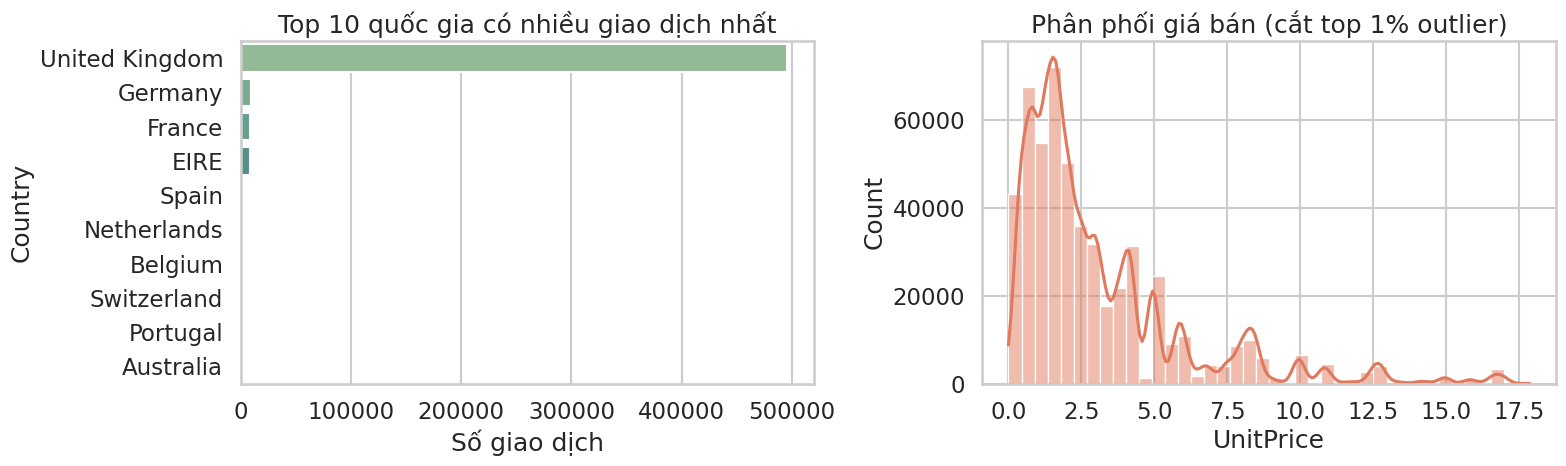

In [36]:
# ====================== 6. TRỰC QUAN HÓA BAN ĐẦU ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_top = raw_dataset['Country'].value_counts().head(10)
sns.barplot(x=country_top.values, y=country_top.index, palette='crest', ax=axes[0])
axes[0].set_title('Top 10 quốc gia có nhiều giao dịch nhất')
axes[0].set_xlabel('Số giao dịch')
axes[0].set_ylabel('Country')

price_sample = raw_dataset.loc[raw_dataset['UnitPrice'] > 0, 'UnitPrice']
sns.histplot(price_sample[price_sample < price_sample.quantile(0.99)], bins=40, kde=True, color='#E07A5F', ax=axes[1])
axes[1].set_title('Phân phối giá bán (cắt top 1% outlier)')
axes[1].set_xlabel('UnitPrice')

plt.tight_layout()
plt.show()

In [37]:
# ====================== 7. EDA & TIỀN XỬ LÝ ======================
print('=== THÔNG TIN TỔNG QUAN ===')
print(raw_dataset.info())

print('\n=== GIÁ TRỊ THIẾU ===')
display(raw_dataset.isnull().sum().sort_values(ascending=False).to_frame('Missing'))

dataset = load_and_clean_data(DATA_PATH)
rfm_dataset = add_business_labels(build_rfm_features(dataset))

print('\n=== DỮ LIỆU SAU KHI LÀM SẠCH ===')
print(f'Số giao dịch còn lại: {len(dataset):,}')
print(f'Số khách hàng còn lại: {len(rfm_dataset):,}')
display(rfm_dataset.head())

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Revenue      541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB
None

=== GIÁ TRỊ THIẾU ===


,Missing
CustomerID,135080
Description,1454
InvoiceNo,0
Quantity,0
StockCode,0
InvoiceDate,0
UnitPrice,0
Country,0
Revenue,0



=== DỮ LIỆU SAU KHI LÀM SẠCH ===
Số giao dịch còn lại: 397,884
Số khách hàng còn lại: 4,338


,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RuleBasedSegment
0,12346,326,1,"77,183.60",1,1,5,Regular Customers
1,12347,2,7,"4,310.00",5,5,5,Best Customers
2,12348,75,4,"1,797.24",2,4,4,At Risk
3,12349,19,1,"1,757.55",4,1,4,Big Spenders
4,12350,310,1,334.40,1,1,2,Regular Customers


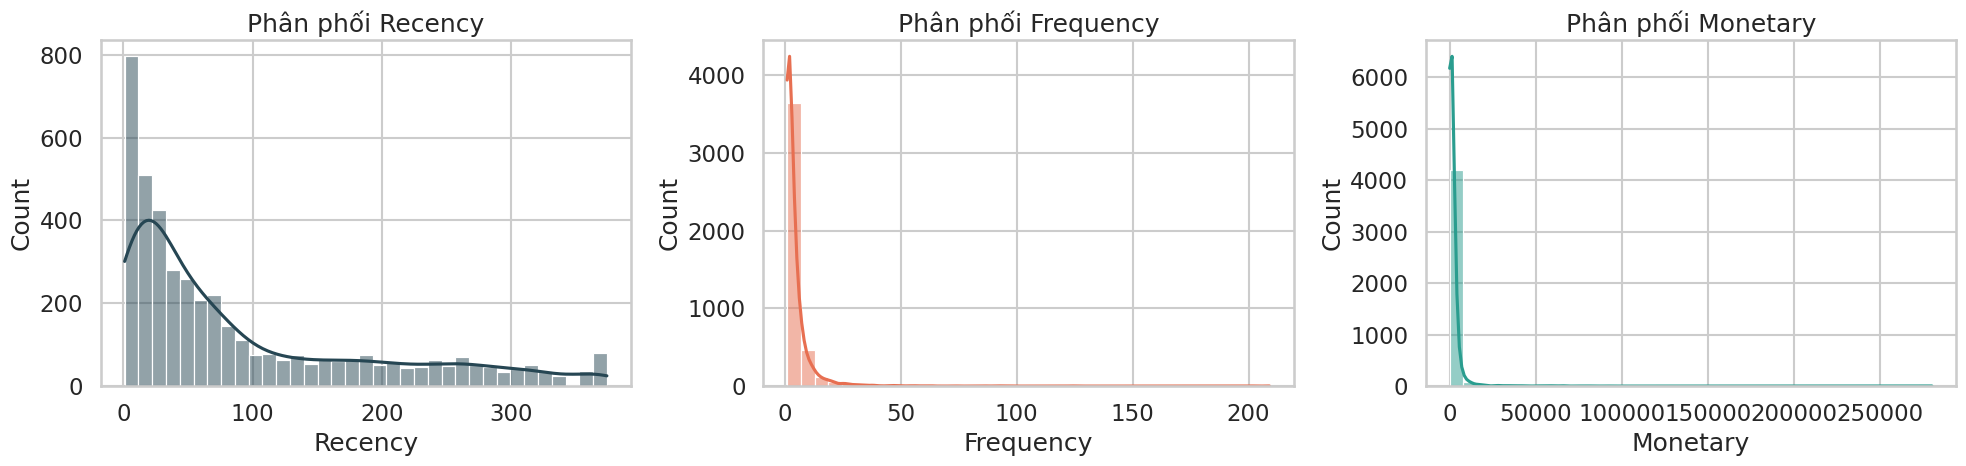

In [38]:
# Trực quan hóa RFM ban đầu
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#264653', '#E76F51', '#2A9D8F']
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], colors):
    sns.histplot(rfm_dataset[col], kde=True, bins=35, color=color, ax=ax)
    ax.set_title(f'Phân phối {col}')
plt.tight_layout()
plt.show()

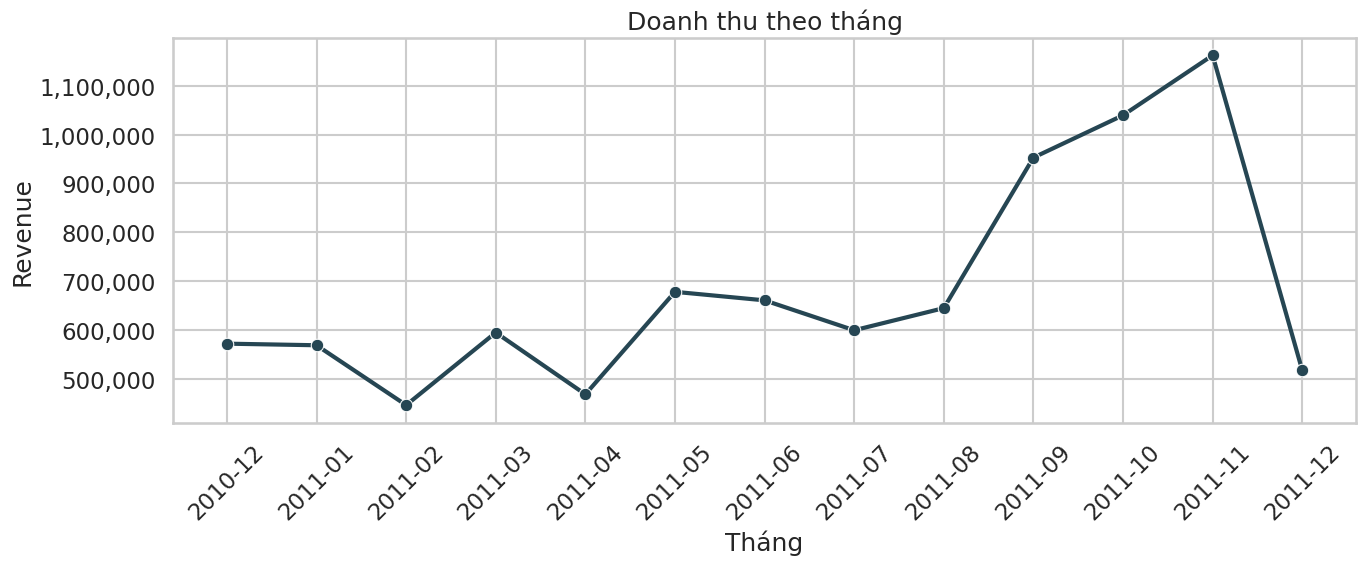

In [39]:
# ====================== 8. PHÂN TÍCH XU HƯỚNG MUA HÀNG ======================
monthly_sales = (
    dataset.assign(YearMonth=dataset['InvoiceDate'].dt.to_period('M').astype(str))
    .groupby('YearMonth')
    .agg(Revenue=('TotalAmount', 'sum'), Orders=('InvoiceNo', 'nunique'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o', linewidth=3, color='#264653', ax=ax1)
ax1.set_title('Doanh thu theo tháng')
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Revenue')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [40]:
# ====================== 9. CHUẨN HÓA DỮ LIỆU ======================
X_scaled = standardize_features(rfm_dataset)
print('Kích thước ma trận đặc trưng:', X_scaled.shape)

Kích thước ma trận đặc trưng: (4338, 3)


In [41]:
# ====================== 10. CHỌN THAM SỐ CHO DBSCAN ======================
min_samples = 8
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, min_samples - 1])

suggested_eps = float(np.quantile(k_distances, 0.97))
print(f'Giá trị eps gợi ý theo quantile 97%: {suggested_eps:.3f}')

Giá trị eps gợi ý theo quantile 97%: 0.535


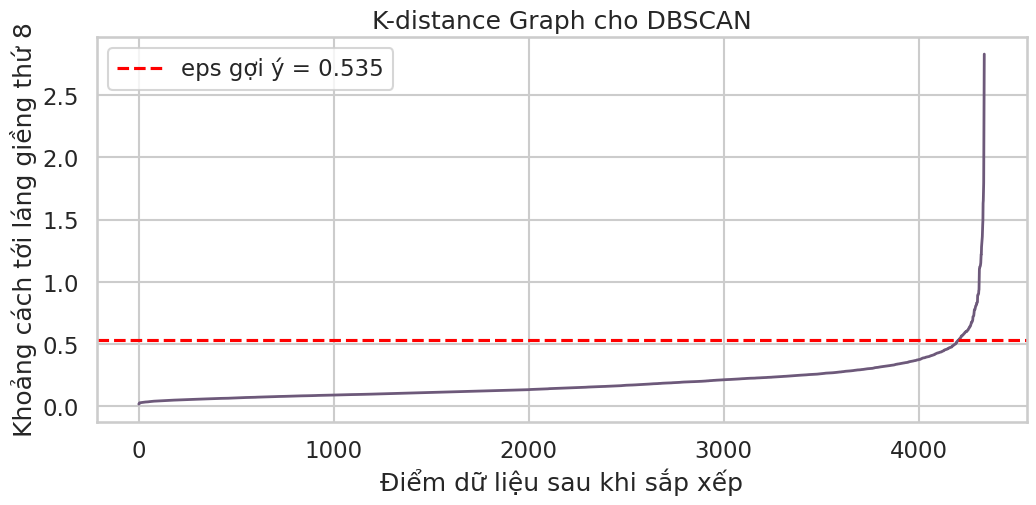

In [42]:
# Biểu đồ K-distance để hỗ trợ chọn eps
plt.figure(figsize=(12, 5))
plt.plot(k_distances, color='#6D597A', linewidth=2)
plt.axhline(suggested_eps, linestyle='--', color='red', label=f'eps gợi ý = {suggested_eps:.3f}')
plt.title('K-distance Graph cho DBSCAN')
plt.xlabel('Điểm dữ liệu sau khi sắp xếp')
plt.ylabel(f'Khoảng cách tới láng giềng thứ {min_samples}')
plt.legend()
plt.show()

In [43]:
# ====================== 11. HUẤN LUYỆN MÔ HÌNH DBSCAN ======================
eps = round(suggested_eps, 3)
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)
rfm_dataset['DBSCAN_Cluster'] = labels

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
num_noise = int((labels == -1).sum())

print(f'Số cụm tìm được: {num_clusters}')
print(f'Số điểm nhiễu (noise): {num_noise}')

if num_clusters >= 2:
    mask = labels != -1
    dbscan_silhouette = silhouette_score(X_scaled[mask], labels[mask])
    print(f'Silhouette Score (bỏ noise): {dbscan_silhouette:.4f}')
else:
    dbscan_silhouette = np.nan
    print('Không đủ cụm để tính silhouette score.')

Số cụm tìm được: 2
Số điểm nhiễu (noise): 61
Silhouette Score (bỏ noise): 0.2935


In [44]:
# ====================== 12. ĐÁNH GIÁ & DIỄN GIẢI KẾT QUẢ ======================
cluster_counts = rfm_dataset['DBSCAN_Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Customers']
display(cluster_counts)

cluster_profile = (
    rfm_dataset[rfm_dataset['DBSCAN_Cluster'] != -1]
    .groupby('DBSCAN_Cluster')
    .agg(
        Customers=('CustomerID', 'count'),
        AvgRecency=('Recency', 'mean'),
        AvgFrequency=('Frequency', 'mean'),
        AvgMonetary=('Monetary', 'mean'),
        DominantRuleSegment=('RuleBasedSegment', lambda x: x.value_counts().idxmax()),
    )
    .round(2)
    .reset_index()
)
display(cluster_profile)

,Cluster,Customers
0,-1,61
1,0,2793
2,1,1484


,DBSCAN_Cluster,Customers,AvgRecency,AvgFrequency,AvgMonetary,DominantRuleSegment
0,0,2793,59.19,5.37,"2,012.68",Best Customers
1,1,1484,157.01,1.00,352.61,Regular Customers


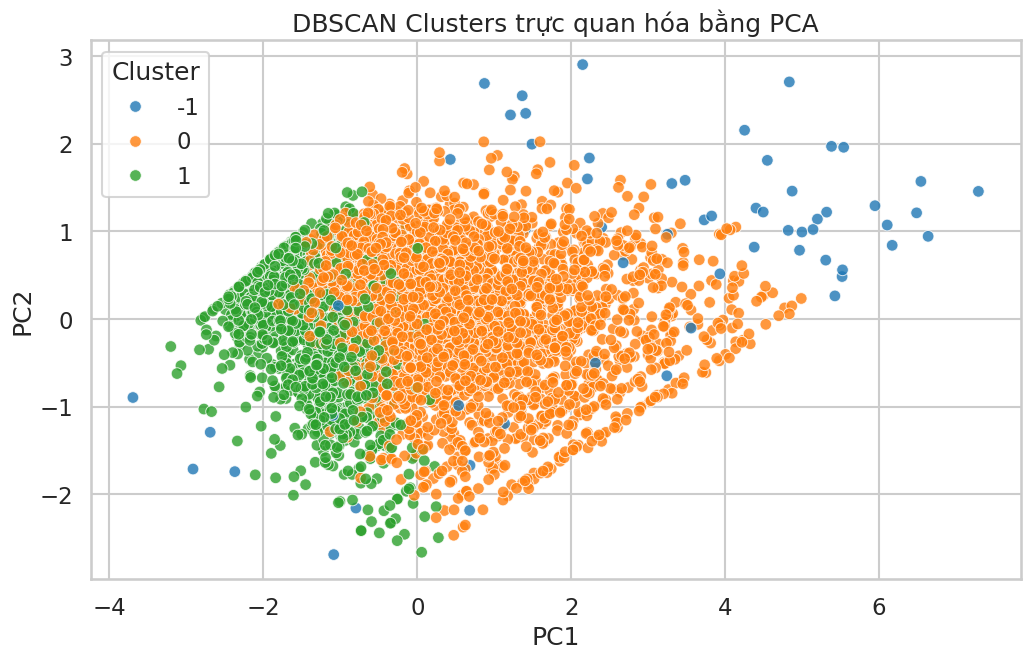

In [45]:
# Trực quan hóa 2D bằng PCA
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    'PC1': rfm_2d[:, 0],
    'PC2': rfm_2d[:, 1],
    'Cluster': labels,
})

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.8,
    s=70,
)
plt.title('DBSCAN Clusters trực quan hóa bằng PCA')
plt.show()

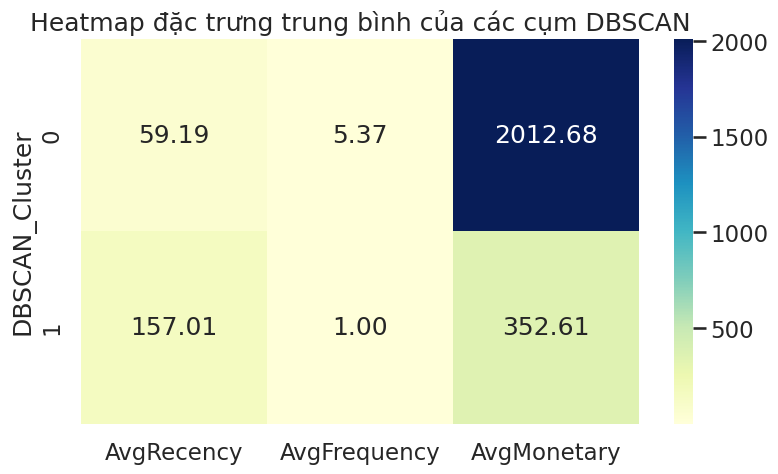

In [46]:
# Heatmap hồ sơ cụm
if len(cluster_profile) > 0:
    heatmap_df = cluster_profile.set_index('DBSCAN_Cluster')[['AvgRecency', 'AvgFrequency', 'AvgMonetary']]
    plt.figure(figsize=(9, 5))
    sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title('Heatmap đặc trưng trung bình của các cụm DBSCAN')
    plt.show()

In [47]:
# ====================== 13. KHÁCH HÀNG GIẢ ĐỊNH ======================
sample_customer = pd.DataFrame([
    {'CustomerID': 'NEW_CUSTOMER', 'Recency': 18, 'Frequency': 7, 'Monetary': 3100.0}
])

reference = pd.concat([
    rfm_dataset[['CustomerID', 'Recency', 'Frequency', 'Monetary']],
    sample_customer,
], ignore_index=True)
reference_scaled = standardize_features(reference)
sample_scaled = reference_scaled[-1]

non_noise = rfm_dataset[rfm_dataset['DBSCAN_Cluster'] != -1].copy()
if len(non_noise) > 0:
    centroid_df = non_noise.groupby('DBSCAN_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
    centroid_ref = pd.concat([
        rfm_dataset[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(0),
        centroid_df[['Recency', 'Frequency', 'Monetary']],
        sample_customer[['Recency', 'Frequency', 'Monetary']]
    ], ignore_index=True)
    centroid_scaled = standardize_features(centroid_ref)
    cluster_points = centroid_scaled[:-1]
    sample_point = centroid_scaled[-1]
    distances = np.linalg.norm(cluster_points - sample_point, axis=1)
    nearest_cluster = int(centroid_df.iloc[np.argmin(distances)]['DBSCAN_Cluster'])
    print('=== THAM CHIẾU KHÁCH HÀNG GIẢ ĐỊNH ===')
    display(sample_customer)
    print(f'Khách hàng giả định gần nhất với cụm DBSCAN: {nearest_cluster}')
    display(cluster_profile[cluster_profile['DBSCAN_Cluster'] == nearest_cluster])
else:
    print('Không có cụm hợp lệ để tham chiếu khách hàng giả định.')

=== THAM CHIẾU KHÁCH HÀNG GIẢ ĐỊNH ===


,CustomerID,Recency,Frequency,Monetary
0,NEW_CUSTOMER,18,7,"3,100.00"


Khách hàng giả định gần nhất với cụm DBSCAN: 0


,DBSCAN_Cluster,Customers,AvgRecency,AvgFrequency,AvgMonetary,DominantRuleSegment
0,0,2793,59.19,5.37,"2,012.68",Best Customers


In [48]:
# ====================== 14. DỰ ĐOÁN XU HƯỚNG TIÊU DÙNG ======================
monthly_trend = build_monthly_features(dataset)
forecast_df, slopes = build_forecast_table(monthly_trend, steps=3)

display(monthly_trend[['MonthLabel', 'Revenue', 'Orders', 'ActiveCustomers', 'Quantity']])
display(forecast_df[['MonthLabel', 'Revenue', 'Orders', 'ActiveCustomers', 'Quantity']])

for metric, slope in slopes.items():
    print(f'{metric}: {classify_trend(slope)} ({slope:,.2f}/tháng)')

,MonthLabel,Revenue,Orders,ActiveCustomers,Quantity
0,2010-12,"572,713.89",1400,885,312265
1,2011-01,"569,445.04",987,741,349098
2,2011-02,"447,137.35",997,758,265622
3,2011-03,"595,500.76",1321,974,348503
4,2011-04,"469,200.36",1149,856,292222
5,2011-05,"678,594.56",1555,1056,373601
6,2011-06,"661,213.69",1393,991,363699
7,2011-07,"600,091.01",1331,949,369420
8,2011-08,"645,343.90",1280,935,398121
9,2011-09,"952,838.38",1755,1266,544897


,MonthLabel,Revenue,Orders,ActiveCustomers,Quantity
0,2011-12,"1,037,466.78","2,111.09","1,440.02","601,076.53"
1,2012-01,"1,089,471.73","2,208.26","1,502.08","630,980.62"
2,2012-02,"1,141,476.68","2,305.43","1,564.15","660,884.72"


Revenue: Tăng (52,004.95/tháng)
Orders: Tăng (97.17/tháng)
ActiveCustomers: Tăng (62.07/tháng)
Quantity: Tăng (29,904.09/tháng)


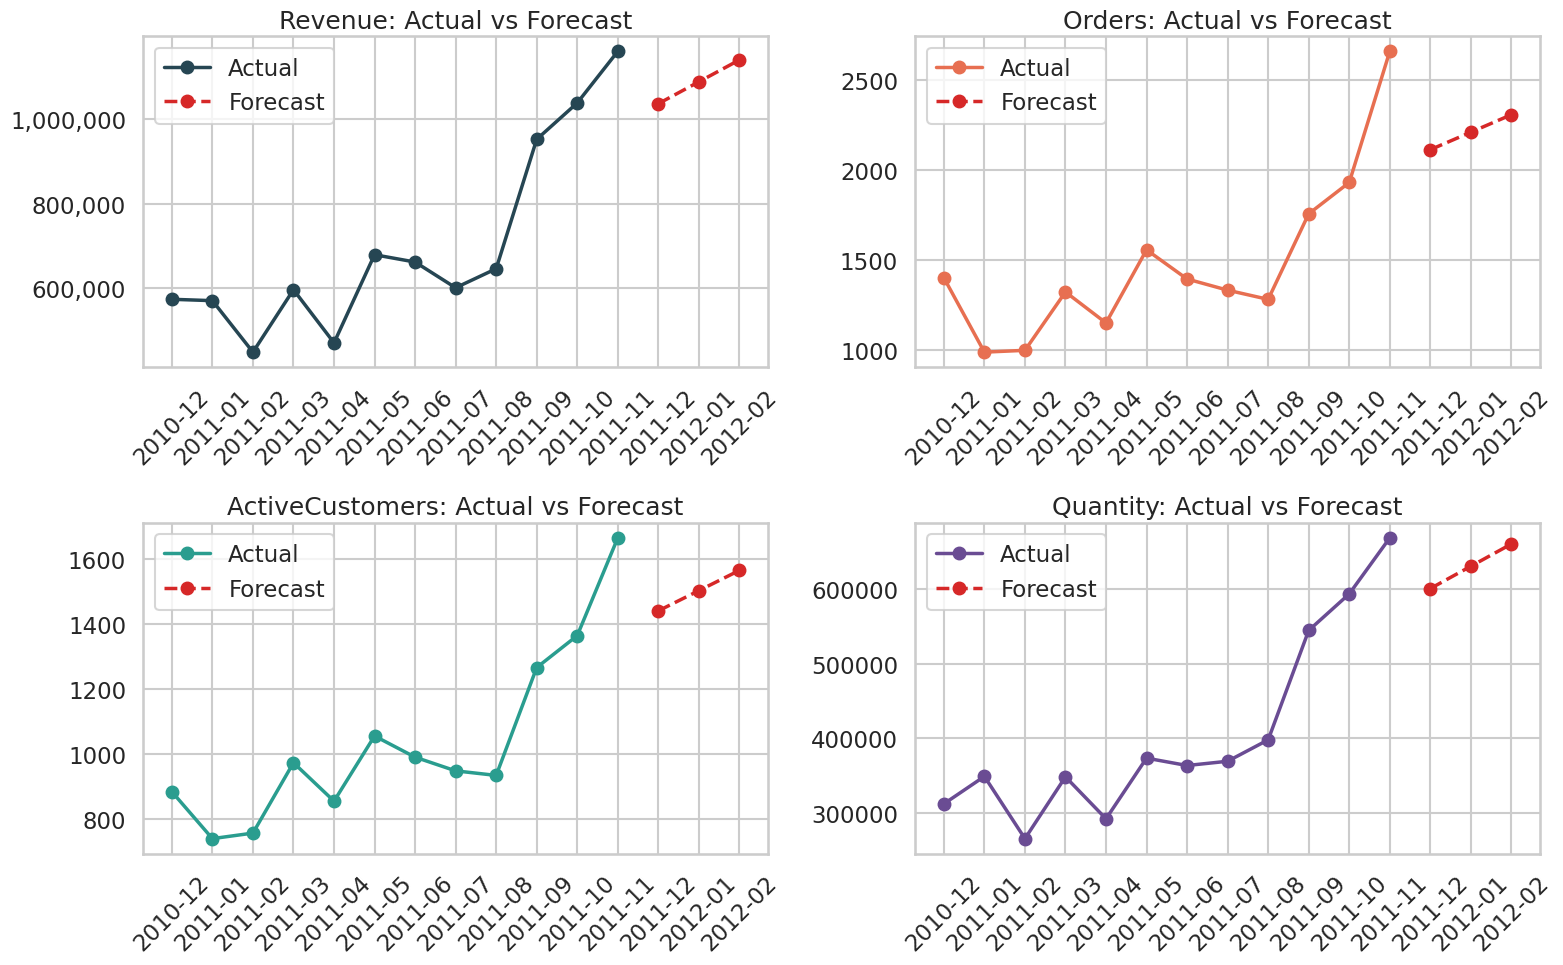

In [49]:
# Trực quan hóa forecast
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['Revenue', 'Orders', 'ActiveCustomers', 'Quantity']
colors = ['#264653', '#E76F51', '#2A9D8F', '#6A4C93']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    ax.plot(monthly_trend['MonthLabel'], monthly_trend[metric], marker='o', linewidth=2.5, color=color, label='Actual')
    ax.plot(forecast_df['MonthLabel'], forecast_df[metric], marker='o', linestyle='--', linewidth=2.5, color='#D62828', label='Forecast')
    ax.set_title(f'{metric}: Actual vs Forecast')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    if metric == 'Revenue':
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 12. Kết luận

- DBSCAN giúp phát hiện các cụm hành vi khách hàng theo mật độ, đồng thời chỉ ra các điểm nhiễu bất thường.
- So với K-Means, DBSCAN hữu ích khi dữ liệu có outlier và không muốn ép mọi điểm vào một cụm.
- Phần khách hàng giả định trong notebook chỉ mang tính tham chiếu, vì DBSCAN không hỗ trợ dự đoán cụm mới trực tiếp.
- Phần dự báo xu hướng tiêu dùng theo tháng giúp bài làm bám sát hơn với tên đề tài.